In [13]:
import numpy as np
import pandas as pd
import seaborn as sns
from empiricaldist import Cdf, Pmf
from utils import decorate, make_joint

sns.set_style('darkgrid')

## 13.1 Improving Reading Ability

In [3]:
df = pd.read_csv('./data/drp_scores.csv', skiprows=21, delimiter='\t')
df.head(3)

,Treatment,Response
0,Treated,24
1,Treated,43
2,Treated,58


In [4]:
grouped = df.groupby('Treatment')
responses = {}

for name, group in grouped:
    responses[name] = group['Response']

In [6]:
responses['Control']

21    42
22    43
23    55
24    26
25    62
26    37
27    33
28    41
29    19
30    54
31    20
32    85
33    46
34    10
35    17
36    60
37    53
38    42
39    37
40    42
41    55
42    28
43    48
Name: Response, dtype: int64

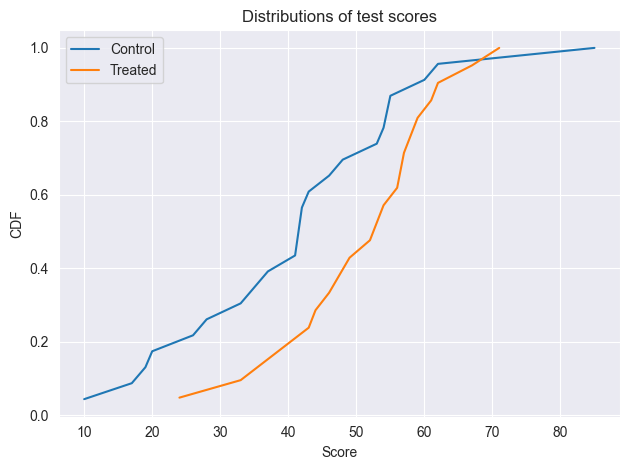

In [10]:
for name, response in responses.items():
    cdf = Cdf.from_seq(response)
    cdf.plot(label=name)
    
decorate(
    xlabel='Score', 
    ylabel='CDF',
    title='Distributions of test scores'
)

## 13.2 Estimating Parameters

In [15]:
def make_uniform(qs, name=None, **options):
    """Make a Pmf that represents a uniform distribution."""
    pmf = Pmf(1.0, qs, **options)
    pmf.normalize()
    if name:
        pmf.index.name = name
    return pmf


qs = np.linspace(20, 80, num=101)
prior_mu = make_uniform(qs, name='mean')

qs = np.linspace(5, 30, num=101)
prior_sigma = make_uniform(qs, name='std')

prior = make_joint(prior_mu, prior_sigma)

In [16]:
data = responses['Control']
data.shape

(23,)